# TASK 4 — Trend Analysis by Release Year

Task Requirements

Organize Netflix content by release_year , 
Calculate yearly content releases ,
Identify growth and decline trends ,
Create trend visualizations ,
Interpret business patterns.

In [1]:
%pip install seaborn
%matplotlib inline

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# importing necessary libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# loading the cleaned dataset

df = pd.read_csv("Netflix_Cleaned.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head(5)

Dataset loaded successfully!
Shape: (8790, 14)


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,date_added_year,date_added_month,date_added_month_name,duration_value
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,2021,9,September,90.0
1,s3,Tv Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",2021,9,September,1.0
2,s6,Tv Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",2021,9,September,1.0
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",2021,9,September,91.0
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",2021,9,September,125.0


In [5]:
# checking release year information

print("Data type of release_year:")
print(df["release_year"].dtype)

print("\nMinimum Release Year:")
print(df["release_year"].min())

print("\nMaximum Release Year:")
print(df["release_year"].max())

Data type of release_year:
int64

Minimum Release Year:
1925

Maximum Release Year:
2021


In [6]:
# calculating number of Netflix titles released each year

year_counts = (
    df["release_year"]
    .value_counts()
    .sort_index()
)

print("Yearly Content Releases:")
print(year_counts)

Yearly Content Releases:
release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1030
2018    1146
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64


In [7]:
# creating a yearly content analysis table

year_analysis = year_counts.reset_index()

year_analysis.columns = [
    "Release_Year",
    "Content_Count"
]

year_analysis.head(20)

,Release_Year,Content_Count
0,1925,1
1,1942,2
2,1943,3
3,1944,3
4,1945,4
5,1946,2
6,1947,1
7,1954,2
8,1955,3
9,1956,2


In [8]:
# displaying content releases from 2000 onwards

recent_years = year_analysis[
    year_analysis["Release_Year"] >= 2000
]

recent_years.head()

,Release_Year,Content_Count
52,2000,37
53,2001,45
54,2002,51
55,2003,59
56,2004,64


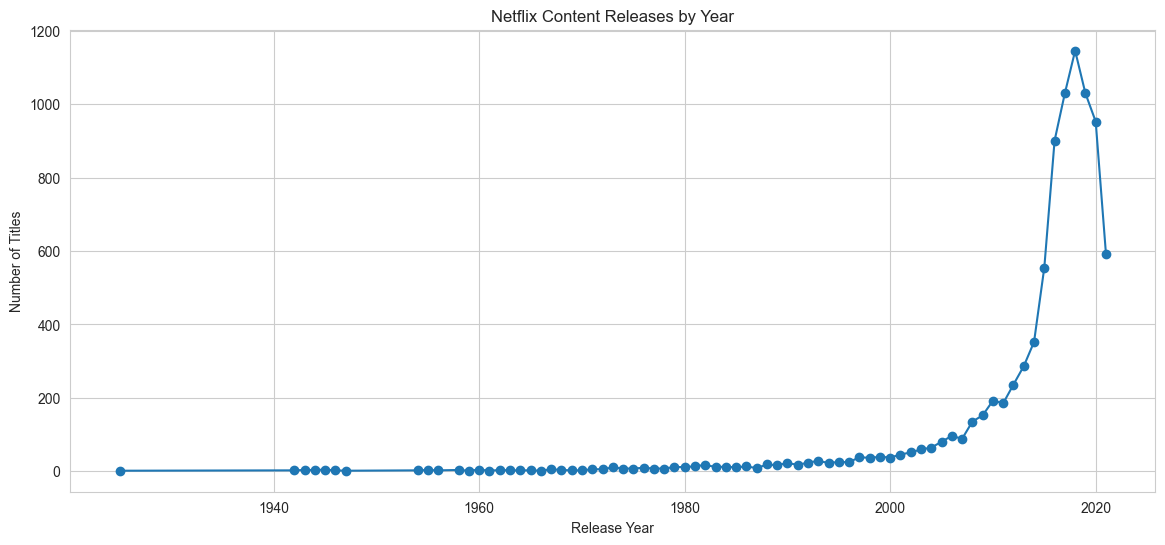

In [9]:
# visualizing Netflix content releases by year

plt.figure(figsize=(14, 6))

plt.plot(
    year_analysis["Release_Year"],
    year_analysis["Content_Count"],
    marker="o"
)

plt.title("Netflix Content Releases by Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

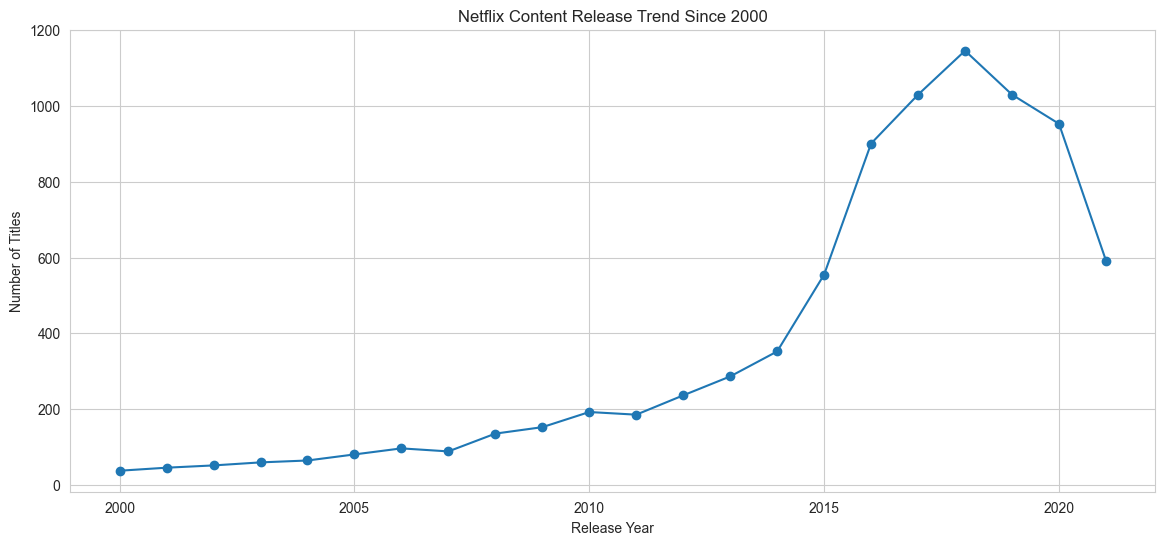

In [10]:
# visualizing the trend from 2000 onwards

plt.figure(figsize=(14, 6))

plt.plot(
    recent_years["Release_Year"],
    recent_years["Content_Count"],
    marker="o"
)

plt.title("Netflix Content Release Trend Since 2000")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

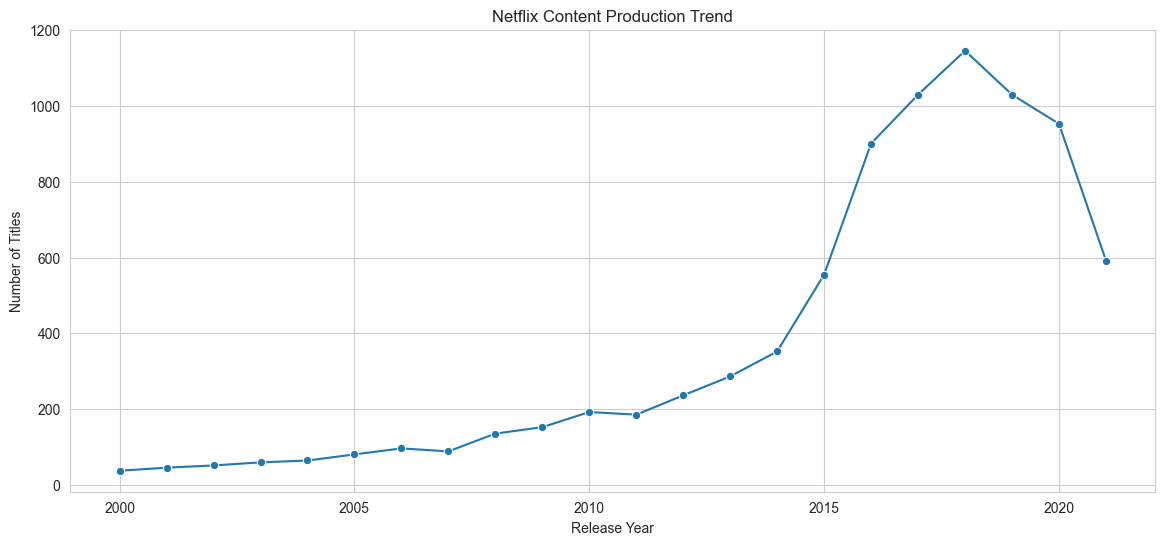

In [11]:
# creating a seaborn trend chart

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=recent_years,
    x="Release_Year",
    y="Content_Count",
    marker="o"
)

plt.title("Netflix Content Production Trend")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

In [12]:
# finding the year with the highest number of releases

peak_year = year_counts.idxmax()
peak_count = year_counts.max()

print("Peak Release Year:", peak_year)
print("Number of Titles Released:", peak_count)

Peak Release Year: 2018
Number of Titles Released: 1146


In [13]:
# finding the year with the lowest number of releases

lowest_year = year_counts.idxmin()
lowest_count = year_counts.min()

print("Lowest Release Year:", lowest_year)
print("Number of Titles:", lowest_count)

Lowest Release Year: 1925
Number of Titles: 1


In [21]:
# calculating yearly releases by content type

year_type = (
    df.groupby(["release_year", "type"])
    .size()
    .reset_index(name="Content_Count")
)

print(year_type.head(5))
print("=" * 44)
print(year_type.tail(5))

   release_year     type  Content_Count
0          1925  Tv Show              1
1          1942    Movie              2
2          1943    Movie              3
3          1944    Movie              3
4          1945    Movie              3
     release_year     type  Content_Count
114          2019  Tv Show            397
115          2020    Movie            517
116          2020  Tv Show            436
117          2021    Movie            277
118          2021  Tv Show            315


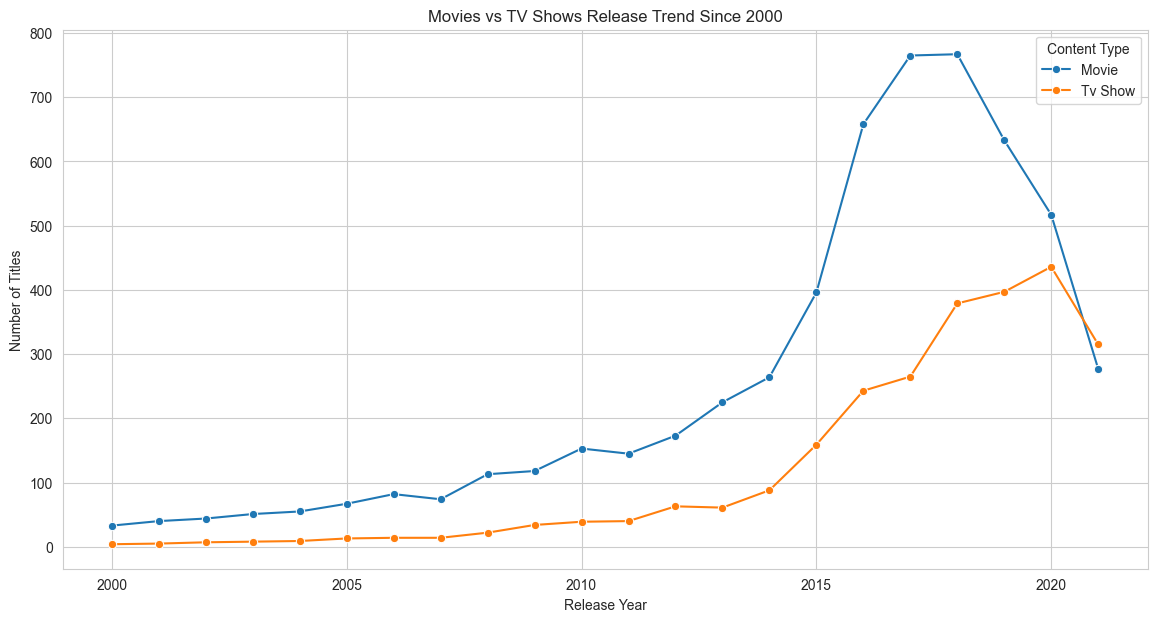

In [22]:
# filtering data from 2000 onwards

recent_year_type = year_type[
    year_type["release_year"] >= 2000
]

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=recent_year_type,
    x="release_year",
    y="Content_Count",
    hue="type",
    marker="o"
)

plt.title("Movies vs TV Shows Release Trend Since 2000")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.legend(title="Content Type")

plt.show()

In [23]:
# finding the years with the highest number of releases

top_release_years = (
    df["release_year"]
    .value_counts()
    .head(10)
)

print("Top 10 Release Years:")
print(top_release_years)

Top 10 Release Years:
release_year
2018    1146
2019    1030
2017    1030
2020     953
2016     901
2021     592
2015     555
2014     352
2013     286
2012     236
Name: count, dtype: int64


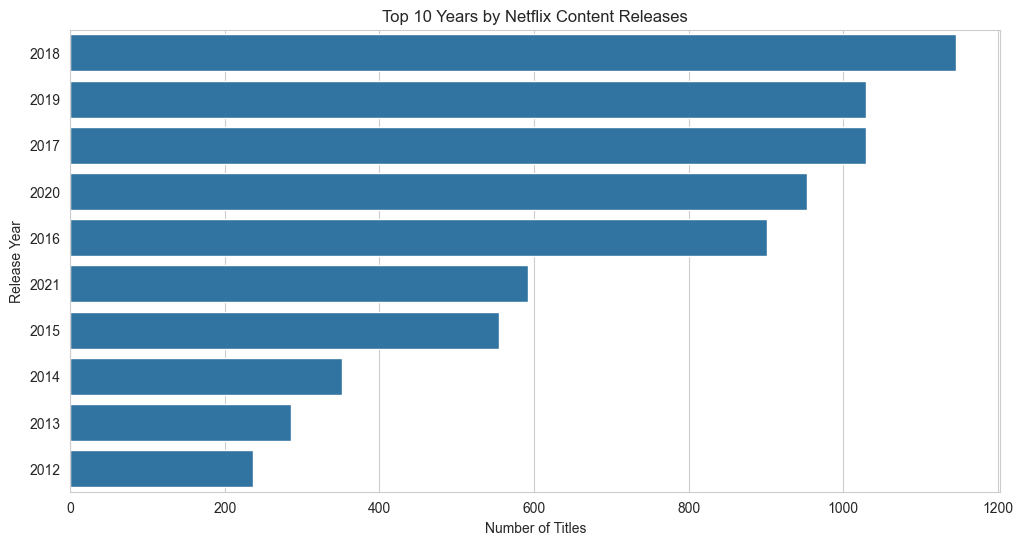

In [24]:
# visualizing top 10 release years

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_release_years.values,
    y=top_release_years.index.astype(str)
)

plt.title("Top 10 Years by Netflix Content Releases")
plt.xlabel("Number of Titles")
plt.ylabel("Release Year")

plt.show()

In [25]:
# calculating year-to-year change

year_analysis["Yearly_Change"] = (
    year_analysis["Content_Count"].diff()
)

year_analysis["Growth_Percentage"] = (
    year_analysis["Content_Count"]
    .pct_change() * 100
)

year_analysis.tail(20)

,Release_Year,Content_Count,Yearly_Change,Growth_Percentage
54,2002,51,6.0,13.333333
55,2003,59,8.0,15.686275
56,2004,64,5.0,8.474576
57,2005,80,16.0,25.000000
58,2006,96,16.0,20.000000
59,2007,88,-8.0,-8.333333
60,2008,135,47.0,53.409091
61,2009,152,17.0,12.592593
62,2010,192,40.0,26.315789
63,2011,185,-7.0,-3.645833


In [26]:
# displaying growth analysis from 2000 onwards

recent_growth = year_analysis[
    year_analysis["Release_Year"] >= 2000
].copy()

recent_growth[
    [
        "Release_Year",
        "Content_Count",
        "Yearly_Change",
        "Growth_Percentage"
    ]
].tail(20)

,Release_Year,Content_Count,Yearly_Change,Growth_Percentage
54,2002,51,6.0,13.333333
55,2003,59,8.0,15.686275
56,2004,64,5.0,8.474576
57,2005,80,16.0,25.000000
58,2006,96,16.0,20.000000
59,2007,88,-8.0,-8.333333
60,2008,135,47.0,53.409091
61,2009,152,17.0,12.592593
62,2010,192,40.0,26.315789
63,2011,185,-7.0,-3.645833


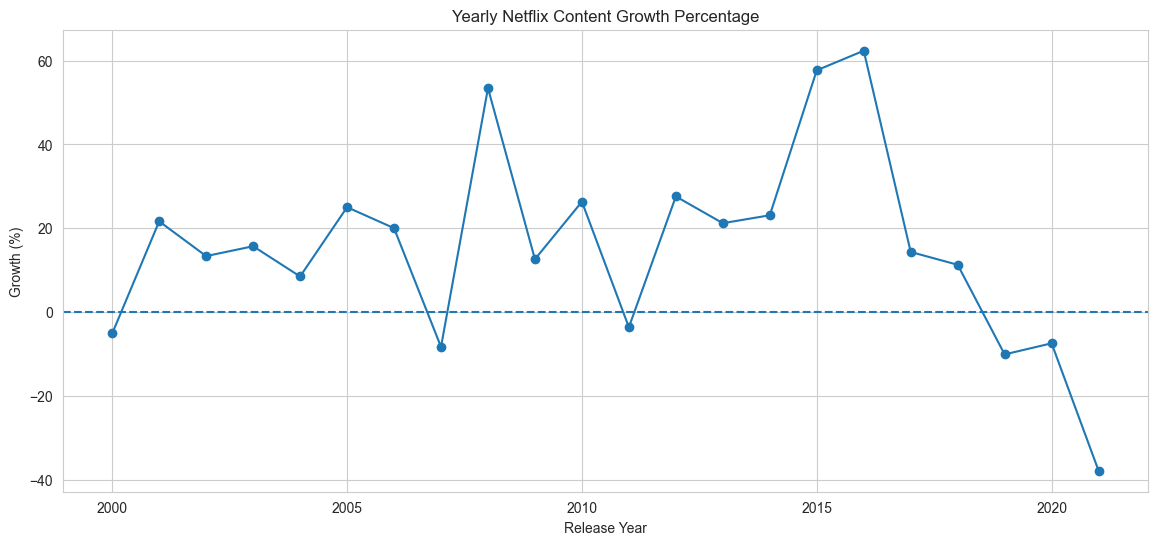

In [27]:
# visualizing yearly growth percentage

plt.figure(figsize=(14, 6))

plt.plot(
    recent_growth["Release_Year"],
    recent_growth["Growth_Percentage"],
    marker="o"
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Yearly Netflix Content Growth Percentage")
plt.xlabel("Release Year")
plt.ylabel("Growth (%)")

plt.show()

In [28]:
# generating business insights

print("=" * 60)
print("           TASK 4 - BUSINESS INSIGHTS")
print("=" * 60)

print(
    f"\n1. Peak release year: {peak_year}"
)

print(
    f"2. Number of titles released during the peak year: "
    f"{peak_count}"
)

print(
    f"3. Lowest release year in the dataset: {lowest_year}"
)

print(
    f"4. Number of titles in that year: {lowest_count}"
)

print(
    "\n5. The release-year analysis helps identify "
    "periods of increasing and decreasing content production."
)

print(
    "6. Comparing Movies and TV Shows shows how the "
    "content mix has changed over time."
)

           TASK 4 - BUSINESS INSIGHTS

1. Peak release year: 2018
2. Number of titles released during the peak year: 1146
3. Lowest release year in the dataset: 1925
4. Number of titles in that year: 1

5. The release-year analysis helps identify periods of increasing and decreasing content production.
6. Comparing Movies and TV Shows shows how the content mix has changed over time.


In [29]:
# exporting yearly analysis

year_analysis.to_csv(
    "Netflix_Year_Analysis.csv",
    index=False
)

print("Yearly analysis exported successfully!")
print("File: Netflix_Year_Analysis.csv")

Yearly analysis exported successfully!
File: Netflix_Year_Analysis.csv
